# 1. Training Set Preprocessing

## 1.1 Data Loading

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import matplotlib.ticker as ticker
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

# 1. Data Loading
# June 2025 - November 2025 as the training set
train_files = glob.glob('/Users/yanmingkuang/Desktop/IDX/CRMLSSold20250[6-9].csv') + \
              glob.glob('/Users/yanmingkuang/Desktop/IDX/CRMLSSold20251[0-1].csv')

print("Number of training files found:", len(train_files))
print("Files:", train_files)

train_df_list = []
for file in train_files:
    temp_train_df = pd.read_csv(file,low_memory=False)
    train_df_list.append(temp_train_df)

train_df = pd.concat(train_df_list, ignore_index=True)

print("Dataset shape:", train_df.shape)



Number of training files found: 6
Files: ['/Users/yanmingkuang/Desktop/IDX/CRMLSSold202509.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202508.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202506.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202507.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202511.csv', '/Users/yanmingkuang/Desktop/IDX/CRMLSSold202510.csv']
Dataset shape: (134265, 78)


## 1.2 Data Cleaning

In [153]:
# 2. Data cleaning

# 2.1 Restrict to single-family residential homes
# Keep backup before filtering
train_raw = train_df.copy()

# Apply the filter
train_df = train_df[
    (train_df['PropertyType'] == 'Residential') & 
    (train_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f"Filtered to single-family: {train_df.shape[0]:,} rows")


# 2.2 Remove top 0.5% and bottom 0.5% of ClosePrice to exclude erroneous / non-economic transactions

lower_threshold = train_df['ClosePrice'].quantile(0.005)   # bottom 0.5%
upper_threshold = train_df['ClosePrice'].quantile(0.995)   # top 0.5%

print(f"\nOutlier removal thresholds (ClosePrice):")
print(f"  Lower (0.5th percentile): ${lower_threshold:,.0f}")
print(f"  Upper (99.5th percentile): ${upper_threshold:,.0f}")

rows_before = len(train_df)
low_outliers  = train_df['ClosePrice'] < lower_threshold
high_outliers = train_df['ClosePrice'] > upper_threshold

print(f"Rows removed (bottom 0.5%): {low_outliers.sum():,}")
print(f"Rows removed (top 0.5%):    {high_outliers.sum():,}")
print(f"Total rows removed:         {low_outliers.sum() + high_outliers.sum():,}")
print(f"Percentage removed:         {((low_outliers.sum() + high_outliers.sum()) / rows_before) * 100:.3f}%")

train_df = train_df[
    (train_df['ClosePrice'] >= lower_threshold) & 
    (train_df['ClosePrice'] <= upper_threshold)
].copy()


# 2.3 Exclude `ListPrice` , `OriginalListPrice`, 'DaysOnMarket'
columns_to_drop = ['ListPrice', 'OriginalListPrice','DaysOnMarket']
train_df = train_df.drop(columns=columns_to_drop, errors='ignore')


# 2.4 Remove rows where LivingArea is <=0
print("Rows with LivingArea == 0:", (train_df['LivingArea'] <= 0).sum())
train_df = train_df[train_df['LivingArea'] > 0].copy()


# 2.5 Remove rows where Latitude or Longitude is missing or invalid

print("\nInvalid Latitude (outside CA range or 0/NaN):")
print(train_df[~train_df['Latitude'].between(32.5, 42.0)]['Latitude'].value_counts(dropna=False))

print("\nInvalid Longitude (outside CA range or 0/NaN):")
print(train_df[~train_df['Longitude'].between(-124.5, -114.0)]['Longitude'].value_counts(dropna=False))

lat_min, lat_max = 32.5, 42.0
lon_min, lon_max = -124.5, -114.0

valid_location = (
    train_df['Latitude'].notna() &
    train_df['Longitude'].notna() &
    train_df['Latitude'].between(lat_min, lat_max) &
    train_df['Longitude'].between(lon_min, lon_max)
)

train_df = train_df[valid_location].copy()

# 2.6 remove illogical/impossible values
logical_values = (
    (train_df['BedroomsTotal'] > 0) &
    (train_df['BathroomsTotalInteger'] > 0) &
    (train_df['LotSizeAcres'] > 0) &
    (train_df['LotSizeArea'] > 0) &
    (train_df['LotSizeSquareFeet'] > 0) &
    (train_df['ParkingTotal'] >= 0) &  # >= 0 to allow 0, only drop negative
    (train_df['LotSizeSquareFeet'] <= 217800) & #realistic max (e.g., 5 acres = 217,800 sq ft)
    (train_df['ParkingTotal'] <= 50) &
    (train_df['GarageSpaces'].isna() | train_df['GarageSpaces'] <= 100) # keep the missing rows
)


# Apply the filter
train_df = train_df[logical_values].copy()

print("\nUpdated min values after removal:")
print("BedroomsTotal min:      ", train_df['BedroomsTotal'].min())
print("BathroomsTotalInteger min:", train_df['BathroomsTotalInteger'].min())
print("LotSizeAcres min:       ", train_df['LotSizeAcres'].min())
print("LotSizeArea min:        ", train_df['LotSizeArea'].min())
print("LotSizeSquareFeet min:  ", train_df['LotSizeSquareFeet'].min())
print("ParkingTotal min:       ", train_df['ParkingTotal'].min())
print("LotSizeSquareFeet max:  ", train_df['LotSizeSquareFeet'].max())
print("ParkingTotal max:       ", train_df['ParkingTotal'].max())
print("GarageSpaces max:       ", train_df['GarageSpaces'].max())

# 2.7 remove duplicate rows with the same ListingIDs and other features
duplicates = train_df[train_df['ListingId'].duplicated(keep=False)].sort_values('ListingId')

print(f"Found {len(duplicates):,} duplicate rows (all occurrences)")
print("\nSample duplicate rows:")
print(duplicates[['ListingId', 'ClosePrice', 'CloseDate', 'City', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']].head(10))

train_df = train_df.drop_duplicates(subset='ListingId', keep='first').copy()


# 2.8 remove columns with >80% missing
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False).round(2)

missing_cols_to_drop = missing_pct[missing_pct > 80].index.tolist()

# show only columns with missing values
print("\nFeatures with missing values (>0%):")
print(missing_pct[missing_pct > 0])

train_df = train_df.drop(columns=missing_cols_to_drop)

# 2.9 log transform ClosePrice
print(train_df["ClosePrice"].isna().sum())
print((train_df["ClosePrice"]<=0).sum())
train_df["log_ClosePrice"] = np.log(train_df["ClosePrice"])

# After all cleaning
print(f"\nTotal rows removed during cleaning: "
      f"{len(train_raw) - len(train_df):,} "
      f"({(len(train_raw) - len(train_df)) / len(train_raw) * 100:.1f}% of original)")

sorted_cols = sorted(train_df.columns)

train_df[sorted_cols].info()



Filtered to single-family: 68,493 rows

Outlier removal thresholds (ClosePrice):
  Lower (0.5th percentile): $190,000
  Upper (99.5th percentile): $8,750,000
Rows removed (bottom 0.5%): 335
Rows removed (top 0.5%):    341
Total rows removed:         676
Percentage removed:         0.987%
Rows with LivingArea == 0: 24

Invalid Latitude (outside CA range or 0/NaN):
Latitude
NaN          4
0.000000     2
27.942879    1
1.000000     1
Name: count, dtype: int64

Invalid Longitude (outside CA range or 0/NaN):
Longitude
 NaN           4
 0.000000      2
 119.300000    1
 119.760500    1
-0.262591      1
 118.390070    1
-112.371086    1
-80.655118     1
 117.310000    1
 1.000000      1
 118.065830    1
 120.432670    1
 117.270769    1
 117.260059    1
-11.230259     1
-112.346328    1
Name: count, dtype: int64

Updated min values after removal:
BedroomsTotal min:       1.0
BathroomsTotalInteger min: 1.0
LotSizeAcres min:        0.0001
LotSizeArea min:         0.0199
LotSizeSquareFeet min:  

## 1.3 Exploratory Data Analysis (EDA)

ClosePrice Summary Statistics:
count    6.552800e+04
mean     1.186286e+06
std      9.515361e+05
min      1.900000e+05
25%      6.263478e+05
50%      8.875000e+05
75%      1.400000e+06
max      8.750000e+06
Name: ClosePrice, dtype: float64


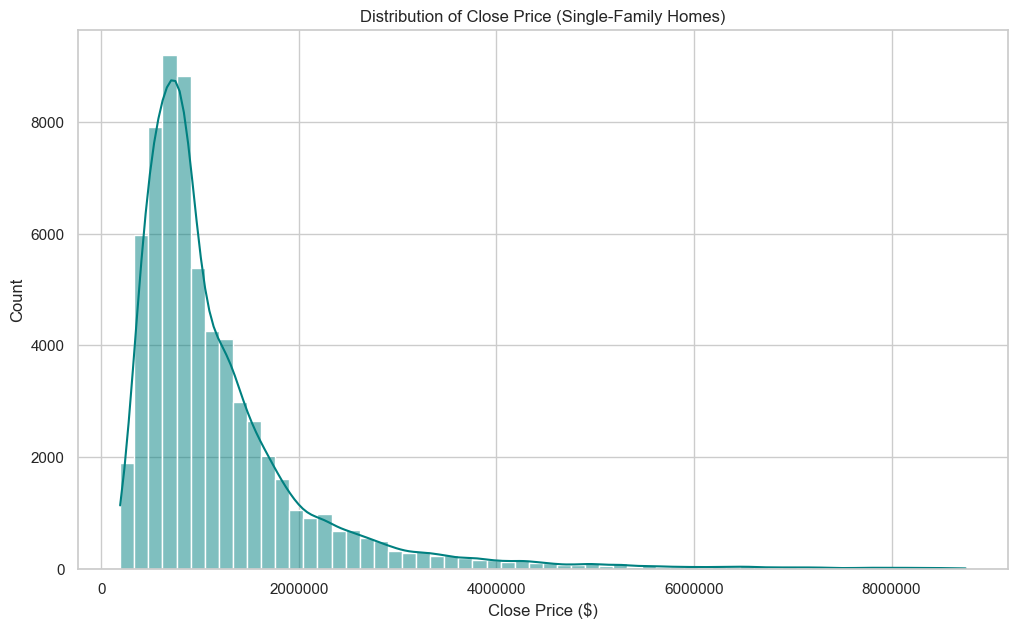


Correlations with ClosePrice (sorted):
ClosePrice               1.000
LivingArea               0.604
BathroomsTotalInteger    0.556
BedroomsTotal            0.347
AssociationFee           0.260
Stories                  0.236
GarageSpaces             0.197
ParkingTotal             0.132
LotSizeArea              0.083
LotSizeAcres             0.075
LotSizeSquareFeet        0.075
Latitude                 0.004
YearBuilt               -0.022
MainLevelBedrooms       -0.085
Longitude               -0.146
Name: ClosePrice, dtype: float64


/var/folders/l2/zp611ys113zd0f_4p1gfzfc80000gn/T/ipykernel_8861/2790771746.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


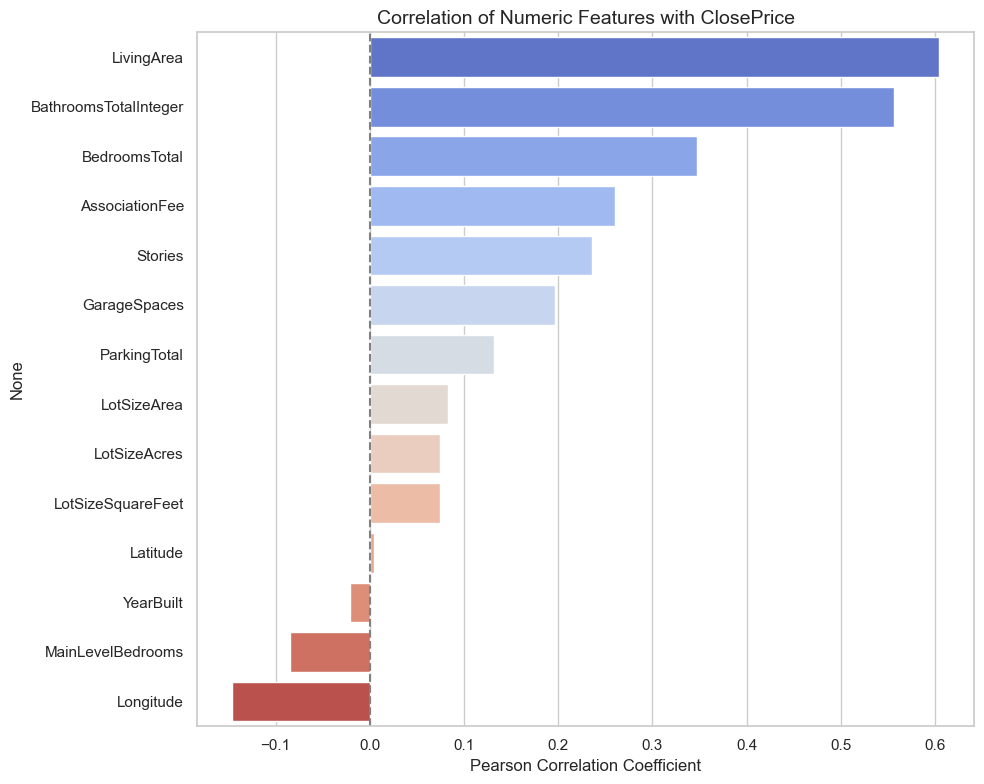

In [154]:
# 3.1 Examine the distribution of the target variable: ClosePrice
# Summary statistics 
print("ClosePrice Summary Statistics:")
print(train_df['ClosePrice'].describe())

# Histogram
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)  # wider figure to fit labels

plt.figure()
sns.histplot(data=train_df, x='ClosePrice', bins=60, kde=True, color='teal')
plt.title('Distribution of Close Price (Single-Family Homes)')
plt.xlabel('Close Price ($)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

# 3.2 Explore the relationships between numeric features and ClosePrice
# Correlation matrix

num_cols = [
    'ClosePrice',           # target
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'LotSizeArea',
    'LotSizeSquareFeet',
    'YearBuilt',
    'ParkingTotal',
    'GarageSpaces',
    'Stories',
    'AssociationFee',
    'Latitude',
    'Longitude',
    'MainLevelBedrooms'
    # You can add others if you think they matter, but most remaining numerics are IDs or empty
]


# Compute correlation matrix
corr_matrix = train_df[num_cols].corr()

# Correlations with ClosePrice only – sorted descending
close_corr = corr_matrix['ClosePrice'].sort_values(ascending=False)

print("\nCorrelations with ClosePrice (sorted):")
print(close_corr.round(3))

# Bar plot – strongest associations
plt.figure(figsize=(10, 8))
sns.barplot(
    x=close_corr.values[1:],           # exclude self-correlation
    y=close_corr.index[1:],
    palette='coolwarm'
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Correlation of Numeric Features with ClosePrice', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()


In [155]:
# 3.2 Explore the relationships between non-numeric features (e.g., categorical) and ClosePrice

from scipy import stats

cat_cols = [
    'CountyOrParish', 
    'Levels', 
    'NewConstructionYN',
    'PoolPrivateYN', 
    'ViewYN', 
    'FireplaceYN', 
    'AttachedGarageYN',
    'AssociationFeeFrequency', 
    'Stories', 
    'Flooring',
    'HighSchoolDistrict',
    'MLSAreaMajor',
    'City', 
]


print("Categorical columns being analyzed:", cat_cols)


def kruskal_test_by_category(df, cat_col, target_col='ClosePrice', min_obs_per_group=10):
    """
    Runs Kruskal-Wallis test on ClosePrice grouped by a categorical column.
    Skips groups with too few observations.
    """
    # Drop NaN in the category or target
    df_valid = df.dropna(subset=[cat_col, target_col]).copy()
    
    # Group prices by category
    groups = []
    group_names = []
    
    for name, group in df_valid.groupby(cat_col):
        prices = group[target_col].values
        if len(prices) >= min_obs_per_group:
            groups.append(prices)
            group_names.append(name)
    
    if len(groups) < 2:
        print(f"Not enough valid groups for {cat_col} (need ≥2 groups with ≥{min_obs_per_group} obs each)")
        return None
    
    # Run Kruskal-Wallis
    # All features except AttachedGarageYN show highly significant differences in ClosePrice across categories (p < 0.05 or much lower).  
    stat, p_value = stats.kruskal(*groups)
    
    print(f"\nKruskal-Wallis Test: {cat_col} vs {target_col}")
    print(f"Number of groups tested: {len(groups)}")
    print(f"Groups tested: {', '.join(map(str, group_names[:10]))}{'...' if len(group_names) > 10 else ''}")
    print(f"Statistic: {stat:.3f}")
    print(f"p-value:   {p_value:.4e}")
    
    if p_value < 0.05:
        print("→ Statistically significant differences (p < 0.05)")
    elif p_value < 0.10:
        print("→ Marginally significant differences (p < 0.10)")
    else:
        print("→ No strong evidence of differences (p ≥ 0.10)")
    
    return stat, p_value
    
# Run Kruskal-Wallis on each
for col in cat_cols:
    if col in train_df.columns:
        kruskal_test_by_category(train_df, col)
    else:
        print(f"Column not found: {col}")


Categorical columns being analyzed: ['CountyOrParish', 'Levels', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN', 'AssociationFeeFrequency', 'Stories', 'Flooring', 'HighSchoolDistrict', 'MLSAreaMajor', 'City']

Kruskal-Wallis Test: CountyOrParish vs ClosePrice
Number of groups tested: 45
Groups tested: Alameda, Butte, Calaveras, Contra Costa, El Dorado, Fresno, Glenn, Imperial, Kern, Kings...
Statistic: 28762.618
p-value:   0.0000e+00
→ Statistically significant differences (p < 0.05)

Kruskal-Wallis Test: Levels vs ClosePrice
Number of groups tested: 11
Groups tested: MultiSplit, MultiSplit,One, One, One,MultiSplit, One,Two, ThreeOrMore, ThreeOrMore,MultiSplit, Two, Two,MultiSplit, Two,One...
Statistic: 5091.387
p-value:   0.0000e+00
→ Statistically significant differences (p < 0.05)

Kruskal-Wallis Test: NewConstructionYN vs ClosePrice
Number of groups tested: 2
Groups tested: False, True
Statistic: 396.264
p-value:   3.5822e-88
→ Statistically signi

## 1.4 Impute Missing values

In [156]:
# 4.1 Impute median (by Zipcodes) for numeric features

In [157]:
# Number of unique ZIP codes
print("Number of unique PostalCode values:", train_df['PostalCode'].nunique())

# Distribution of properties per ZIP code
print("\nProperties per PostalCode (sorted descending):")
zip_counts = train_df['PostalCode'].value_counts()
print(zip_counts.head(20))   # top 20 most common
print("\n... (total unique ZIPs:", len(zip_counts), ")")
print("\nZIPs with very few properties:")
print(zip_counts.tail(10))   # rarest ZIPs

# Summary stats on counts
# Some zip codes have only 1 or few propertities -> group zip codes by the first 3 digits
print("\nSummary of ZIP code frequencies:")
print(zip_counts.describe().round(0))

# Convert PostalCode to string 
train_df['PostalCode'] = train_df['PostalCode'].astype(str)

# Extract first 3 digits as ZIP prefix
train_df['ZIP_prefix'] = train_df['PostalCode'].str[:3]

# Number of unique ZIP prefixes
num_unique_prefixes = train_df['ZIP_prefix'].nunique()
print(f"Number of unique ZIP prefixes (first 3 digits): {num_unique_prefixes}")

print("Unique ZIP prefixes and their frequencies (sorted by prefix):")
print(train_df['ZIP_prefix'].value_counts().sort_index())



Number of unique PostalCode values: 1643

Properties per PostalCode (sorted descending):
PostalCode
92253    425
92345    421
92584    360
92596    351
92223    351
92592    331
92562    283
92308    281
93536    278
92530    273
92563    267
92336    265
93065    262
92203    258
94513    252
92211    248
93535    244
93551    244
92220    238
92392    236
Name: count, dtype: int64

... (total unique ZIPs: 1643 )

ZIPs with very few properties:
PostalCode
94546-3156    1
94563-3114    1
93609         1
94619-2809    1
94502-6518    1
94526-2940    1
94611-5531    1
94803-2798    1
95205-9204    1
95919         1
Name: count, dtype: int64

Summary of ZIP code frequencies:
count    1643.0
mean       40.0
std        56.0
min         1.0
25%         1.0
50%        12.0
75%        60.0
max       425.0
Name: count, dtype: float64
Number of unique ZIP prefixes (first 3 digits): 64
Unique ZIP prefixes and their frequencies (sorted by prefix):
ZIP_prefix
202      1
205      5
835      1
864   

In [158]:
# Convert to numeric, invalid become NaN
train_df['ZIP_prefix_num'] = pd.to_numeric(train_df['ZIP_prefix'], errors='coerce')

# Valid CA ZIP mask
valid_zip_mask = (
    train_df['ZIP_prefix_num'].notna() &
    (train_df['ZIP_prefix_num'] >= 900) &
    (train_df['ZIP_prefix_num'] <= 961)
)

# Apply filter
train_df = train_df[valid_zip_mask].copy()

# Drop the temporary column
train_df = train_df.drop(columns=['ZIP_prefix_num'], errors='ignore')


In [159]:
# Summary table: missing % 
numeric_summary = pd.DataFrame({
    'Column': num_cols,
    'Non-Null Count': [train_df[col].notna().sum() for col in num_cols],
    'Missing %': [train_df[col].isna().sum() / len(train_df) * 100 for col in num_cols]
}).round(2)

print("\nNumerical Summary:")
print(numeric_summary.sort_values('Missing %', ascending=False))


Numerical Summary:
                   Column  Non-Null Count  Missing %
14      MainLevelBedrooms           40529      38.14
11         AssociationFee           46550      28.95
10                Stories           58831      10.20
9            GarageSpaces           62893       4.01
7               YearBuilt           65489       0.04
0              ClosePrice           65517       0.00
1              LivingArea           65517       0.00
2           BedroomsTotal           65517       0.00
3   BathroomsTotalInteger           65517       0.00
4            LotSizeAcres           65517       0.00
5             LotSizeArea           65517       0.00
6       LotSizeSquareFeet           65517       0.00
8            ParkingTotal           65517       0.00
12               Latitude           65517       0.00
13              Longitude           65517       0.00


In [160]:
# List of numeric columns we're imputing
num_cols_to_impute = [
    'MainLevelBedrooms',
    'AssociationFee',
    'Stories',
    'GarageSpaces',
    'YearBuilt'
]

print(train_df['ZIP_prefix'].dtype)



object


In [161]:
# Check for each column: how many missing values are in ZIP prefixes with no non-missing data
print("Check for ZIP_prefix median fallback need:")
for col in num_cols_to_impute:
    # ZIP prefixes with at least one non-missing value for this column
    zip_has_data = train_df[train_df[col].notna()]['ZIP_prefix'].unique()
    
    # Missing values in ZIP prefixes that have NO data for this column
    missing_in_no_data_zips = train_df[
        (train_df[col].isna()) & 
        (~train_df['ZIP_prefix'].isin(zip_has_data))
    ].shape[0]
    
    total_missing = train_df[col].isna().sum()
    
    print(f"\n{col}:")
    print(f"  Total missing: {total_missing:,}")
    print(f"  Missing in ZIP prefixes with no data for {col}: {missing_in_no_data_zips:,}")
    print(f"  % of missing that would need global fallback: "
          f"{(missing_in_no_data_zips / total_missing * 100) if total_missing > 0 else 0:.2f}%")

Check for ZIP_prefix median fallback need:

MainLevelBedrooms:
  Total missing: 24,988
  Missing in ZIP prefixes with no data for MainLevelBedrooms: 552
  % of missing that would need global fallback: 2.21%

AssociationFee:
  Total missing: 18,967
  Missing in ZIP prefixes with no data for AssociationFee: 0
  % of missing that would need global fallback: 0.00%

Stories:
  Total missing: 6,686
  Missing in ZIP prefixes with no data for Stories: 0
  % of missing that would need global fallback: 0.00%

GarageSpaces:
  Total missing: 2,624
  Missing in ZIP prefixes with no data for GarageSpaces: 0
  % of missing that would need global fallback: 0.00%

YearBuilt:
  Total missing: 28
  Missing in ZIP prefixes with no data for YearBuilt: 0
  % of missing that would need global fallback: 0.00%


In [162]:
# Compute medians by ZIP_prefix
medians_by_zip = {}
for col in num_cols_to_impute:
    medians_by_zip[col] = train_df.groupby('ZIP_prefix')[col].median()

# Global fallback medians (only used when ZIP has no data)
global_medians = {col: train_df[col].median() for col in num_cols_to_impute}

# Imputation function
def impute_by_zip(row, col):
    if pd.isna(row[col]):
        zip_median = medians_by_zip[col].get(row['ZIP_prefix'], None)
        if pd.notna(zip_median):
            return zip_median
        return global_medians[col]
    return row[col]

# Apply imputation
for col in num_cols_to_impute:
    train_df[col] = train_df.apply(lambda row: impute_by_zip(row, col), axis=1)

# Verification
print("\nMissing values after ZIP-prefix median imputation:")
print(train_df[num_cols_to_impute].isna().sum())

print("\nUpdated descriptive statistics:")
print(train_df[num_cols_to_impute].describe().round(2))


Missing values after ZIP-prefix median imputation:
MainLevelBedrooms    0
AssociationFee       0
Stories              0
GarageSpaces         0
YearBuilt            0
dtype: int64

Updated descriptive statistics:
       MainLevelBedrooms  AssociationFee   Stories  GarageSpaces  YearBuilt
count            65517.0        65517.00  65517.00      65517.00   65517.00
mean                 2.3          100.15      1.32          1.98    1975.24
std                  1.2          250.04      0.47          0.90      27.50
min                  0.0            0.00      1.00          0.00    1776.00
25%                  2.0            0.00      1.00          2.00    1955.00
50%                  2.0            0.00      1.00          2.00    1975.00
75%                  3.0          165.00      2.00          2.00    1997.00
max                 44.0        10500.00      2.00         40.00    2026.00


In [163]:
# Summary table: missing % and unique count for each
cat_summary = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [train_df[col].notna().sum() for col in cat_cols],
    'Missing %': [train_df[col].isna().sum() / len(train_df) * 100 for col in cat_cols],
    'Unique Values': [train_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(cat_summary.sort_values('Missing %', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
7   AssociationFeeFrequency           16276      75.16              4
9                  Flooring           43279      33.94            233
10       HighSchoolDistrict           48690      25.68            388
11             MLSAreaMajor           55495      15.30            956
6          AttachedGarageYN           58201      11.17              2
4                    ViewYN           59045       9.88              2
3             PoolPrivateYN           60435       7.76              2
2         NewConstructionYN           60495       7.67              2
1                    Levels           60917       7.02             16
5               FireplaceYN           65472       0.07              2
12                     City           65502       0.02            839
0            CountyOrParish           65517       0.00             54
8                   Stories           65517       0.00              

In [164]:
cat_cols_to_impute = [
    'AssociationFeeFrequency',
    'Flooring',
    'HighSchoolDistrict',
    'MLSAreaMajor',
    'AttachedGarageYN',
    'ViewYN',
    'PoolPrivateYN',
    'NewConstructionYN',
    'Levels',
    'FireplaceYN',
    'City'
]

In [165]:
# Compute mode (most frequent) per ZIP_prefix for each categorical column
modes_by_zip = {}
for col in cat_cols_to_impute:
    modes_by_zip[col] = train_df.groupby('ZIP_prefix')[col].agg(lambda x: x.mode()[0] if not x.mode().empty else pd.NA)

# Global fallback modes
global_modes = {col: train_df[col].mode()[0] if not train_df[col].mode().empty else pd.NA for col in cat_cols_to_impute}

# Imputation function: ZIP-prefix mode first, global mode fallback
def impute_cat_by_zip(row, col):
    if pd.isna(row[col]):
        zip_mode = modes_by_zip[col].get(row['ZIP_prefix'], None)
        if pd.notna(zip_mode):
            return zip_mode
        return global_modes[col]
    return row[col]

# Apply imputation to each categorical column
for col in cat_cols_to_impute:
    print(f"Imputing {col} using ZIP-prefix mode...")
    train_df[col] = train_df.apply(lambda row: impute_cat_by_zip(row, col), axis=1)

# Verification
print("\nMissing values after imputation:")
print(train_df[cat_cols_to_impute].isna().sum())

print("\nUpdated descriptive statistics:")
print(train_df[cat_cols_to_impute].describe().round(2))

Imputing AssociationFeeFrequency using ZIP-prefix mode...
Imputing Flooring using ZIP-prefix mode...
Imputing HighSchoolDistrict using ZIP-prefix mode...
Imputing MLSAreaMajor using ZIP-prefix mode...
Imputing AttachedGarageYN using ZIP-prefix mode...
Imputing ViewYN using ZIP-prefix mode...
Imputing PoolPrivateYN using ZIP-prefix mode...
Imputing NewConstructionYN using ZIP-prefix mode...
Imputing Levels using ZIP-prefix mode...
Imputing FireplaceYN using ZIP-prefix mode...
Imputing City using ZIP-prefix mode...

Missing values after imputation:
AssociationFeeFrequency    0
Flooring                   0
HighSchoolDistrict         0
MLSAreaMajor               0
AttachedGarageYN           0
ViewYN                     0
PoolPrivateYN              0
NewConstructionYN          0
Levels                     0
FireplaceYN                0
City                       0
dtype: int64

Updated descriptive statistics:
       AssociationFeeFrequency     Flooring   HighSchoolDistrict  \
count         

## 1.5 Encoding

In [166]:
categorical_summary = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [train_df[col].notna().sum() for col in cat_cols],
    'Missing %': [train_df[col].isna().sum() / len(train_df) * 100 for col in cat_cols],
    'Unique Values': [train_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(categorical_summary.sort_values('Unique Values', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
11             MLSAreaMajor           65517        0.0            956
12                     City           65517        0.0            839
10       HighSchoolDistrict           65517        0.0            388
9                  Flooring           65517        0.0            233
0            CountyOrParish           65517        0.0             54
1                    Levels           65517        0.0             16
7   AssociationFeeFrequency           65517        0.0              4
8                   Stories           65517        0.0              3
2         NewConstructionYN           65517        0.0              2
3             PoolPrivateYN           65517        0.0              2
4                    ViewYN           65517        0.0              2
5               FireplaceYN           65517        0.0              2
6          AttachedGarageYN           65517        0.0              

In [167]:
# I don't think we need to use MLSAreaMajor, CountyOrParish, or City in our model as we already have Zip codes
# print(train_df['MLSAreaMajor'].value_counts(dropna=False)) 
# print(train_df['CountyOrParish'].value_counts(dropna=False)) # We might not need to use this in our model as we already have Zip code and City
# print(train_df['City'].value_counts(dropna=False))

In [168]:
# For these high-cardinality features (HighSchoolDistrict, Flooring), use target encoding (also called mean encoding)
# -> reduces each category to a single numeric value (e.g., mean ClosePrice in that category)
# -> adds 1 column per feature
print(train_df['HighSchoolDistrict'].value_counts(dropna=False))
print(train_df['Flooring'].value_counts(dropna=False))

HighSchoolDistrict
Los Angeles Unified       6919
Other                     4304
San Ramon Valley          3955
Beaumont                  2182
San Diego Unified         1679
                          ... 
Fort Bragg Unified           1
Westwood                     1
Washington Colony            1
Lindsay Unified              1
Belmont-Redwood Shores       1
Name: count, Length: 388, dtype: int64
Flooring
Carpet,Tile                            17246
Wood                                   10874
Tile,Wood                               4584
Laminate                                4427
Carpet,Tile,Wood                        3113
                                       ...  
Bamboo,Brick,Wood                          1
Laminate,Stone,Vinyl                       1
Bamboo,SeeRemarks                          1
Concrete,SeeRemarks,Tile,Vinyl,Wood        1
Bamboo,Stone,Tile,Wood                     1
Name: count, Length: 233, dtype: int64


In [169]:
# Target encoding function (fits on train)
def target_encode_fit(df, cat_col, target_col='ClosePrice'):
    means = df.groupby(cat_col)[target_col].mean()
    global_mean = df[target_col].mean()
    encoded_col = f'{cat_col}_target_mean'
    df[encoded_col] = df[cat_col].map(means).fillna(global_mean)
    return df, means, global_mean

# Apply and save the mappings
train_df, highschool_means, highschool_global = target_encode_fit(train_df, 'HighSchoolDistrict')
train_df, flooring_means, flooring_global = target_encode_fit(train_df, 'Flooring')

print("Target-encoded columns added on train:")
print(train_df[['HighSchoolDistrict', 'HighSchoolDistrict_target_mean',
                'Flooring', 'Flooring_target_mean']].head(10))

Target-encoded columns added on train:
             HighSchoolDistrict  HighSchoolDistrict_target_mean  \
5              Redlands Unified                    7.047386e+05   
6     Saddleback Valley Unified                    1.490935e+06   
8   Santa Monica-Malibu Unified                    3.949061e+06   
9   Huntington Beach Union High                    1.700693e+06   
10             Pasadena Unified                    1.968931e+06   
12               Orange Unified                    1.415627e+06   
13               Tustin Unified                    1.991484e+06   
18          Los Angeles Unified                    1.477354e+06   
21               Irvine Unified                    2.252643e+06   
22         Newport Mesa Unified                    3.414613e+06   

             Flooring  Flooring_target_mean  
5         Carpet,Tile          8.750132e+05  
6   Carpet,Vinyl,Wood          1.066886e+06  
8     Stone,Tile,Wood          2.841358e+06  
9               Vinyl          9.662395

In [170]:
# recode Levels
print(train_df['Levels'].value_counts(dropna=False)) 

# make levels variable more simple
def recode_levels_final(x):
    if pd.isna(x):
        return x
    if "ThreeOrMore" in x:
        return "ThreeOrMore"
    elif "Two" in x:
        return "Two"
    elif "One" in x:
        return "One"
    elif "MultiSplit" in x:
        return "MultiSplit"
    else:
        return "Other"

train_df["Levels_final"] = train_df["Levels"].apply(recode_levels_final)

train_df["Levels_final"].value_counts()

Levels
One                           42252
Two                           20651
ThreeOrMore                    1168
MultiSplit                      887
Two,One                         195
One,Two                         149
Two,MultiSplit                   98
One,MultiSplit                   32
ThreeOrMore,MultiSplit           31
MultiSplit,One                   21
Two,ThreeOrMore                  19
One,ThreeOrMore                   8
One,Two,MultiSplit                2
ThreeOrMore,One                   2
Two,ThreeOrMore,MultiSplit        1
One,Two,ThreeOrMore               1
Name: count, dtype: int64


Levels_final
One            42305
Two            21095
ThreeOrMore     1230
MultiSplit       887
Name: count, dtype: int64

In [171]:
# For low-cardinality features (Levels_final, AssociationFeeFrequency, Stories)
# use one-hot encoding

# For NewConstructionYN, PoolPrivateYN, ViewYN, FireplaceYN, AttachedGarageYN, already binary, no encoding needed

low_card_cols = [
    'Levels_final', 
    'AssociationFeeFrequency',
    'Stories'
]

# Recode from float to object
train_df['Stories'] = train_df['Stories'].astype(str).replace('nan', 'Missing')
print("Converted Stories to object dtype. New dtype:", train_df['Stories'].dtype)
print("Unique Stories values now:", train_df['Stories'].unique())

# One-hot encode
dummies = pd.get_dummies(
    train_df[low_card_cols],
    prefix=low_card_cols,
    drop_first=True,
    dtype=int
)

# Add to DataFrame
train_df = pd.concat([train_df.drop(columns=low_card_cols), dummies], axis=1)

print(f"Added {dummies.shape[1]} new binary columns")
print("New shape:", train_df.shape)
print("\nNew one-hot columns from Stories (example):")
print([c for c in dummies.columns if 'Stories' in c])


Converted Stories to object dtype. New dtype: object
Unique Stories values now: ['1.0' '2.0' '1.5']
Added 8 new binary columns
New shape: (65517, 67)

New one-hot columns from Stories (example):
['Stories_1.5', 'Stories_2.0']


## 1.6 Scaling

In [172]:
# Add PPSF
train_df['PPSF'] = train_df['ClosePrice'] / train_df['LivingArea']
print(train_df['PPSF'].describe())

# PPSF has a higher correlation with log_ClosePrice than LivingArea
print(train_df[['LivingArea', 'log_ClosePrice', 'PPSF']].corr()['log_ClosePrice'].round(4))

# PPSF and LivingArea are very weakly correlated 
print(train_df[['LivingArea', 'PPSF']].corr()['PPSF'].round(4))


count    65517.000000
mean       595.160761
std        344.186293
min         71.377587
25%        348.776224
50%        529.637761
75%        737.915408
max       6366.047745
Name: PPSF, dtype: float64
LivingArea        0.5718
log_ClosePrice    1.0000
PPSF              0.7108
Name: log_ClosePrice, dtype: float64
LivingArea   -0.0446
PPSF          1.0000
Name: PPSF, dtype: float64


In [173]:
# Agenda: #3 Normalize / scale numerical features
# Apply StandardScaler: Subtracts mean, divides by standard deviation
# Narrow it down to LivingArea, LotSizeSquareFeet, AssociationFee, which spans several orders of magnitudes

num_cols_to_scale = [           
    'LivingArea',
    'LotSizeSquareFeet',
    'AssociationFee',
    'PPSF'
]
    
print(train_df[num_cols_to_scale].describe().round(2))

# Choose StandardScaler: subtracts mean of data and divides by sd 
# -> reduce the effect of outliers/extreme values
scaler = StandardScaler()
scaled_values = scaler.fit_transform(train_df[num_cols_to_scale])

# Create new scaled columns
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f"{col}_std" for col in num_cols_to_scale],
    index=train_df.index
)

# Add to main DataFrame
train_df = pd.concat([train_df, scaled_df], axis=1)

print("\nfirst 5 rows:")
print(train_df[[f"{col}_std" for col in num_cols_to_scale]].head())

print("\nScaled columns summary:")
print(train_df[[f"{col}_std" for col in num_cols_to_scale]].describe().round(2))



       LivingArea  LotSizeSquareFeet  AssociationFee      PPSF
count    65517.00           65517.00        65517.00  65517.00
mean      2017.36           12677.01          100.15    595.16
std        931.08           21914.30          250.04    344.19
min        105.00               2.20            0.00     71.38
25%       1388.00            5663.00            0.00    348.78
50%       1811.00            7234.00            0.00    529.64
75%       2416.00           10125.00          165.00    737.92
max      14168.00          217800.00        10500.00   6366.05

first 5 rows:
    LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std  PPSF_std
5         0.443191               0.085926           -0.400555 -0.746372
6        -0.220562              -0.427898            0.619300  0.796216
8         1.230457               0.652729           -0.400555  5.639850
9        -0.179748              -0.407409            0.447324  0.665818
10        5.558810               1.683571           -0.400

## 1.7 Feature Engineering

In [174]:
# Create distance to coast
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Define several major coastal points (lat, lon)
coastal_points = [
    (34.0100, -118.4960),  # Santa Monica Beach (LA area)
    (37.8199, -122.4786),  # Pacific coast near Golden Gate / SF
    (32.7157, -117.1611),  # San Diego harbor/coast
    (36.6002, -121.8947),  # Monterey Bay coast
    (40.8021, -124.1637)   # Northern CA coast proxy
]


# Compute min distance to any coast for each property
def min_distance_to_coast(row):
    distances = [haversine(row['Latitude'], row['Longitude'], lat, lon) for lat, lon in coastal_points]
    return min(distances)

train_df['dist_to_coast_km'] = train_df.apply(min_distance_to_coast, axis=1)

print(train_df['dist_to_coast_km'].describe().round(2))

count    65517.00
mean        72.58
std         48.83
min          0.00
25%         34.06
50%         61.40
75%        105.18
max        335.42
Name: dist_to_coast_km, dtype: float64


In [175]:
# Create BedBathRatio
#train_df['BedBathRatio'] = train_df['BedroomsTotal'] / train_df['BathroomsTotalInteger']
#print(train_df['BedBathRatio'].describe())

#BedBathRatio is not really an improvement over raw BedroomsTotal and BathroomsTotalInteger 
#print(train_df[['BedroomsTotal', 'BathroomsTotalInteger', 'log_ClosePrice', 'BedBathRatio']].corr()['log_ClosePrice'].round(4))


In [176]:
# Define reference year
REFERENCE_YEAR = 2026

# Create Age column
train_df['Age'] = REFERENCE_YEAR - train_df['YearBuilt']

In [177]:
# One hot encode ZIP_prefix
zip_dummies_train = pd.get_dummies(
    train_df['ZIP_prefix'],
    prefix='ZIP_prefix',
    drop_first=True,
    dtype=int
)

# Add to train
train_df = pd.concat([train_df.drop(columns=['ZIP_prefix']), zip_dummies_train], axis=1)

print(f"Added {zip_dummies_train.shape[1]} ZIP_prefix dummy columns to train")
print("Train shape after:", train_df.shape)


Added 56 ZIP_prefix dummy columns to train
Train shape after: (65517, 129)


## 1.8 Train Set Cleaning Complete

In [178]:
# Last step of cleaning: drop irrelevant columns
cols_to_drop = [
    'ListAgentFirstName',
    'ListAgentLastName',
    'ListOfficeName',
    'BuyerOfficeName',
    'CoListOfficeName',
    'ListAgentFullName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ListAgentAOR',
    'BuyerAgentAOR',
    'ListAgentEmail',
    'UnparsedAddress',
    'SubdivisionName',
    'BuyerOfficeAOR',
    'StreetNumberNumeric'
    
]

# Save CLEAN data
train_df_clean = train_df.drop(columns=cols_to_drop).copy()

train_df_clean.info()

train_df_clean.to_csv('train_df_clean.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 65517 entries, 5 to 134257
Columns: 108 entries, Flooring to ZIP_prefix_961
dtypes: bool(5), float64(24), int64(66), object(13)
memory usage: 52.3+ MB


# 2. Test Set Preprocessing

## 2.1 Data Cleaning

In [180]:
# December 2025 as the test set
test_df = pd.read_csv('/Users/yanmingkuang/Desktop/IDX/CRMLSSold202512.csv')
print("Dataset shape:", test_df.shape)


Dataset shape: (20538, 78)


In [181]:
# 8.1 Restrict to single-family residential homes
# Keep backup before filtering
test_raw = test_df.copy()

# Apply the filter
test_df = test_df[
    (test_df['PropertyType'] == 'Residential') & 
    (test_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f"Filtered to single-family: {test_df.shape[0]:,} rows")


# 8.2 Remove top 0.5% and bottom 0.5% of ClosePrice to exclude erroneous / non-economic transactions

lower_threshold = test_df['ClosePrice'].quantile(0.005)   # bottom 0.5%
upper_threshold = test_df['ClosePrice'].quantile(0.995)   # top 0.5%

print(f"\nOutlier removal thresholds (ClosePrice):")
print(f"  Lower (0.5th percentile): ${lower_threshold:,.0f}")
print(f"  Upper (99.5th percentile): ${upper_threshold:,.0f}")

rows_before = len(test_df)
low_outliers  = test_df['ClosePrice'] < lower_threshold
high_outliers = test_df['ClosePrice'] > upper_threshold

print(f"Rows removed (bottom 0.5%): {low_outliers.sum():,}")
print(f"Rows removed (top 0.5%):    {high_outliers.sum():,}")
print(f"Total rows removed:         {low_outliers.sum() + high_outliers.sum():,}")
print(f"Percentage removed:         {((low_outliers.sum() + high_outliers.sum()) / rows_before) * 100:.3f}%")

test_df = test_df[
    (test_df['ClosePrice'] >= lower_threshold) & 
    (test_df['ClosePrice'] <= upper_threshold)
].copy()


# 8.3 Exclude `ListPrice` , `OriginalListPrice`, 'DaysOnMarket'
columns_to_drop = ['ListPrice', 'OriginalListPrice','DaysOnMarket']
test_df = test_df.drop(columns=columns_to_drop, errors='ignore')


# 8.4 Remove rows where LivingArea is <=0
print("Rows with LivingArea == 0:", (test_df['LivingArea'] <= 0).sum())
test_df = test_df[test_df['LivingArea'] > 0].copy()


# 8.5 Remove rows where Latitude or Longitude is missing or invalid

print("\nInvalid Latitude (outside CA range or 0/NaN):")
print(test_df[~test_df['Latitude'].between(32.5, 42.0)]['Latitude'].value_counts(dropna=False))

print("\nInvalid Longitude (outside CA range or 0/NaN):")
print(test_df[~test_df['Longitude'].between(-124.5, -114.0)]['Longitude'].value_counts(dropna=False))

lat_min, lat_max = 32.5, 42.0
lon_min, lon_max = -124.5, -114.0

valid_location = (
    test_df['Latitude'].notna() &
    test_df['Longitude'].notna() &
    test_df['Latitude'].between(lat_min, lat_max) &
    test_df['Longitude'].between(lon_min, lon_max)
)

test_df = test_df[valid_location].copy()

# 8.6 remove illogical/impossible values
logical_values = (
    (test_df['BedroomsTotal'] > 0) &
    (test_df['BathroomsTotalInteger'] > 0) &
    (test_df['LotSizeAcres'] > 0) &
    (test_df['LotSizeArea'] > 0) &
    (test_df['LotSizeSquareFeet'] > 0) &
    (test_df['ParkingTotal'] >= 0) &  # >= 0 to allow 0, only drop negative
    (test_df['LotSizeSquareFeet'] <= 217800) & #realistic max (e.g., 5 acres = 217,800 sq ft)
    (test_df['ParkingTotal'] <= 50) &
    (test_df['GarageSpaces'].isna() | test_df['GarageSpaces'] <= 100) # keep the missing rows
)


# Apply the filter
test_df = test_df[logical_values].copy()

print("\nUpdated min values after removal:")
print("BedroomsTotal min:      ", test_df['BedroomsTotal'].min())
print("BathroomsTotalInteger min:", test_df['BathroomsTotalInteger'].min())
print("LotSizeAcres min:       ", test_df['LotSizeAcres'].min())
print("LotSizeArea min:        ", test_df['LotSizeArea'].min())
print("LotSizeSquareFeet min:  ", test_df['LotSizeSquareFeet'].min())
print("ParkingTotal min:       ", test_df['ParkingTotal'].min())
print("LotSizeSquareFeet max:  ", test_df['LotSizeSquareFeet'].max())
print("ParkingTotal max:       ", test_df['ParkingTotal'].max())
print("GarageSpaces max:       ", test_df['GarageSpaces'].max())

# 8.7 remove duplicate rows with the same ListingIDs and other features
duplicates = test_df[test_df['ListingId'].duplicated(keep=False)].sort_values('ListingId')

print(f"Found {len(duplicates):,} duplicate rows (all occurrences)")
print("\nSample duplicate rows:")
print(duplicates[['ListingId', 'ClosePrice', 'CloseDate', 'City', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']].head(10))

test_df = test_df.drop_duplicates(subset='ListingId', keep='first').copy()


# 8.8 remove columns with >80% missing
missing_pct = (test_df.isna().mean() * 100).sort_values(ascending=False).round(2)

missing_cols_to_drop = missing_pct[missing_pct > 80].index.tolist()

# show only columns with missing values
print("\nFeatures with missing values (>0%):")
print(missing_pct[missing_pct > 0])

test_df = test_df.drop(columns=missing_cols_to_drop)

# 8.9 log transform ClosePrice
print(test_df["ClosePrice"].isna().sum())
print((test_df["ClosePrice"]<=0).sum())
test_df["log_ClosePrice"] = np.log(test_df["ClosePrice"])

# After all cleaning
print(f"\nTotal rows removed during cleaning: "
      f"{len(test_raw) - len(test_df):,} "
      f"({(len(test_raw) - len(test_df)) / len(test_raw) * 100:.1f}% of original)")

sorted_cols = sorted(test_df.columns)

test_df[sorted_cols].info()



Filtered to single-family: 10,455 rows

Outlier removal thresholds (ClosePrice):
  Lower (0.5th percentile): $179,000
  Upper (99.5th percentile): $8,586,500
Rows removed (bottom 0.5%): 52
Rows removed (top 0.5%):    53
Total rows removed:         105
Percentage removed:         1.004%
Rows with LivingArea == 0: 3

Invalid Latitude (outside CA range or 0/NaN):
Latitude
0.000000     3
NaN          2
43.784440    1
31.786721    1
31.853002    1
Name: count, dtype: int64

Invalid Longitude (outside CA range or 0/NaN):
Longitude
 0.000000     3
 NaN          2
-88.787868    1
Name: count, dtype: int64

Updated min values after removal:
BedroomsTotal min:       1.0
BathroomsTotalInteger min: 1.0
LotSizeAcres min:        0.0002
LotSizeArea min:         0.04
LotSizeSquareFeet min:   6.72
ParkingTotal min:        0.0
LotSizeSquareFeet max:   217800.0
ParkingTotal max:        50.0
GarageSpaces max:        20.0
Found 0 duplicate rows (all occurrences)

Sample duplicate rows:
Empty DataFrame
Colu

## 2.2 Impute Missing Values

In [182]:
# Extract first 3 digits as ZIP prefix
test_df['ZIP_prefix'] = test_df['PostalCode'].str[:3]

# Number of unique ZIP prefixes
num_unique_prefixes = test_df['ZIP_prefix'].nunique()
print(f"Number of unique ZIP prefixes (first 3 digits): {num_unique_prefixes}")

print("Unique ZIP prefixes and their frequencies (sorted by prefix):")
print(test_df['ZIP_prefix'].value_counts().sort_index())

# Convert to numeric, invalid become NaN
test_df['ZIP_prefix_num'] = pd.to_numeric(test_df['ZIP_prefix'], errors='coerce')

# Valid CA ZIP mask
valid_zip_mask = (
    test_df['ZIP_prefix_num'].notna() &
    (test_df['ZIP_prefix_num'] >= 900) &
    (test_df['ZIP_prefix_num'] <= 961)
)

# Apply filter
test_df = test_df[valid_zip_mask].copy()

# Drop the temporary column
test_df = test_df.drop(columns=['ZIP_prefix_num'], errors='ignore')


Number of unique ZIP prefixes (first 3 digits): 57
Unique ZIP prefixes and their frequencies (sorted by prefix):
ZIP_prefix
900    437
902    266
903     19
904     15
905     41
906    215
907    154
908    120
910    103
911     66
912     52
913    604
914     92
915     25
916     56
917    584
918      9
919    135
920    478
921    294
922    603
923    776
924    101
925    925
926    513
927     92
928    407
929      1
930    247
931      6
932     45
933     62
934    224
935    226
936     55
937     26
939    105
940    133
941     19
943     10
944     23
945    693
946    134
947     45
948     40
949      4
950    160
951    115
952     15
953    134
954     72
956     21
957      7
958     17
959    152
960     16
961      1
Name: count, dtype: int64


In [183]:
# For numerical features: apply the same imputation function using train-computed medians
for col in num_cols_to_impute:
    print(f"Imputing {col} on test set using train ZIP-prefix medians...")
    test_df[col] = test_df.apply(lambda row: impute_by_zip(row, col), axis=1)

# Verification
print("\nMissing values in test after imputation:")
print(test_df[num_cols_to_impute].isna().sum())

print("\nTest set descriptive statistics after imputation:")
print(test_df[num_cols_to_impute].describe().round(2))

Imputing MainLevelBedrooms on test set using train ZIP-prefix medians...
Imputing AssociationFee on test set using train ZIP-prefix medians...
Imputing Stories on test set using train ZIP-prefix medians...
Imputing GarageSpaces on test set using train ZIP-prefix medians...
Imputing YearBuilt on test set using train ZIP-prefix medians...

Missing values in test after imputation:
MainLevelBedrooms    0
AssociationFee       0
Stories              0
GarageSpaces         0
YearBuilt            0
dtype: int64

Test set descriptive statistics after imputation:
       MainLevelBedrooms  AssociationFee  Stories  GarageSpaces  YearBuilt
count            9990.00         9990.00  9990.00       9990.00    9990.00
mean                2.33           97.79     1.31          1.97    1975.41
std                 1.25          228.22     0.46          0.89      27.84
min                 0.00            0.00     1.00          0.00    1876.00
25%                 2.00            0.00     1.00          2.00  

In [184]:
# For categorical features: Apply the same imputation function using train-computed modes
for col in cat_cols_to_impute:
    print(f"Imputing {col} on test set using train ZIP-prefix modes...")
    test_df[col] = test_df.apply(lambda row: impute_cat_by_zip(row, col), axis=1)

# Verification
print("\nMissing values in test after imputation:")
print(test_df[cat_cols_to_impute].isna().sum())

print("\nTest set descriptive statistics after imputation:")
print(test_df[cat_cols_to_impute].describe().round(2))

Imputing AssociationFeeFrequency on test set using train ZIP-prefix modes...
Imputing Flooring on test set using train ZIP-prefix modes...
Imputing HighSchoolDistrict on test set using train ZIP-prefix modes...
Imputing MLSAreaMajor on test set using train ZIP-prefix modes...
Imputing AttachedGarageYN on test set using train ZIP-prefix modes...
Imputing ViewYN on test set using train ZIP-prefix modes...
Imputing PoolPrivateYN on test set using train ZIP-prefix modes...
Imputing NewConstructionYN on test set using train ZIP-prefix modes...
Imputing Levels on test set using train ZIP-prefix modes...
Imputing FireplaceYN on test set using train ZIP-prefix modes...
Imputing City on test set using train ZIP-prefix modes...

Missing values in test after imputation:
AssociationFeeFrequency    0
Flooring                   0
HighSchoolDistrict         0
MLSAreaMajor               0
AttachedGarageYN           0
ViewYN                     0
PoolPrivateYN              0
NewConstructionYN          

## 2.3 Encoding

In [185]:
categorical_summary_test = pd.DataFrame({
    'Column': cat_cols,
    'Non-Null Count': [test_df[col].notna().sum() for col in cat_cols],
    'Missing %': [test_df[col].isna().sum() / len(test_df) * 100 for col in cat_cols],
    'Unique Values': [test_df[col].nunique() for col in cat_cols]
}).round(2)

print("\nCategorical Summary:")
print(categorical_summary_test.sort_values('Unique Values', ascending=False))


Categorical Summary:
                     Column  Non-Null Count  Missing %  Unique Values
11             MLSAreaMajor            9990        0.0            781
12                     City            9990        0.0            625
10       HighSchoolDistrict            9990        0.0            319
9                  Flooring            9990        0.0            132
0            CountyOrParish            9990        0.0             47
1                    Levels            9990        0.0             13
7   AssociationFeeFrequency            9990        0.0              4
8                   Stories            9990        0.0              3
2         NewConstructionYN            9990        0.0              2
3             PoolPrivateYN            9990        0.0              2
4                    ViewYN            9990        0.0              2
5               FireplaceYN            9990        0.0              2
6          AttachedGarageYN            9990        0.0              

In [186]:
# Reuse the mappings computed from train
# (highschool_means, highschool_global, flooring_means, flooring_global)

# Apply mapping to test (lookup only — no groupby, no new means)
test_df['HighSchoolDistrict_target_mean'] = test_df['HighSchoolDistrict'].map(highschool_means).fillna(highschool_global)
test_df['Flooring_target_mean'] = test_df['Flooring'].map(flooring_means).fillna(flooring_global)

print("Target-encoded columns added on test (using train mappings):")
print(test_df[['HighSchoolDistrict', 'HighSchoolDistrict_target_mean',
               'Flooring', 'Flooring_target_mean']].head(10))

print("\nMissing encoded values in test (should be very few):")
print(test_df[['HighSchoolDistrict_target_mean', 'Flooring_target_mean']].isna().sum())

Target-encoded columns added on test (using train mappings):
       HighSchoolDistrict  HighSchoolDistrict_target_mean            Flooring  \
0        San Ramon Valley                    1.246723e+06    Carpet,Tile,Wood   
2     Los Angeles Unified                    1.477354e+06         Carpet,Wood   
3                   Other                    1.758170e+06           Tile,Wood   
7        San Jose Unified                    1.845997e+06           Tile,Wood   
9                   Other                    1.758170e+06           Tile,Wood   
10     Capistrano Unified                    1.973110e+06          Vinyl,Wood   
11           Mount Diablo                    1.072897e+06  Laminate,Tile,Wood   
13       Temecula Unified                    8.354489e+05    Carpet,Tile,Wood   
14  San Francisco Unified                    1.409091e+06          SeeRemarks   
16   Laguna Beach Unified                    3.360104e+06         Carpet,Wood   

    Flooring_target_mean  
0           1.699990

In [187]:
# recode Levels
print(test_df['Levels'].value_counts(dropna=False)) 

# make levels variable more simple
def recode_levels_final(x):
    if pd.isna(x):
        return x
    if "ThreeOrMore" in x:
        return "ThreeOrMore"
    elif "Two" in x:
        return "Two"
    elif "One" in x:
        return "One"
    elif "MultiSplit" in x:
        return "MultiSplit"
    else:
        return "Other"

test_df["Levels_final"] = test_df["Levels"].apply(recode_levels_final)

test_df["Levels_final"].value_counts()

Levels
One                       6508
Two                       3066
ThreeOrMore                193
MultiSplit                 133
Two,One                     43
One,Two                     20
Two,MultiSplit              11
ThreeOrMore,MultiSplit       6
One,MultiSplit               3
MultiSplit,One               2
One,ThreeOrMore              2
ThreeOrMore,One              2
Two,ThreeOrMore              1
Name: count, dtype: int64


Levels_final
One            6513
Two            3140
ThreeOrMore     204
MultiSplit      133
Name: count, dtype: int64

In [188]:
# For low-cardinality features (Levels_final, AssociationFeeFrequency, Stories)
# use one-hot encoding

# For NewConstructionYN, PoolPrivateYN, ViewYN, FireplaceYN, AttachedGarageYN, already binary, no encoding needed

low_card_cols = [
    'Levels_final', 
    'AssociationFeeFrequency',
    'Stories'
]

# Recode from float to object
test_df['Stories'] = test_df['Stories'].astype(str).replace('nan', 'Missing')
print("Converted Stories to object dtype. New dtype:", test_df['Stories'].dtype)
print("Unique Stories values now:", test_df['Stories'].unique())

# One-hot encode
dummies = pd.get_dummies(
    test_df[low_card_cols],
    prefix=low_card_cols,
    drop_first=True,
    dtype=int
)

# Add to DataFrame
test_df = pd.concat([test_df.drop(columns=low_card_cols), dummies], axis=1)

print(f"Added {dummies.shape[1]} new binary columns")
print("New shape:", test_df.shape)
print("\nNew one-hot columns from Stories (example):")
print([c for c in dummies.columns if 'Stories' in c])


Converted Stories to object dtype. New dtype: object
Unique Stories values now: ['1.0' '2.0' '1.5']
Added 8 new binary columns
New shape: (9990, 67)

New one-hot columns from Stories (example):
['Stories_1.5', 'Stories_2.0']


## 2.4 Scaling

In [189]:
# Add PPSF
test_df['PPSF'] = test_df['ClosePrice'] / test_df['LivingArea']
print(test_df['PPSF'].describe())

# PPSF has a higher correlation with log_ClosePrice than LivingArea
print(test_df[['LivingArea', 'log_ClosePrice', 'PPSF']].corr()['log_ClosePrice'].round(4))

# PPSF and LivingArea are very weakly correlated 
print(test_df[['LivingArea', 'PPSF']].corr()['PPSF'].round(4))

count     9990.000000
mean       573.694385
std        353.734538
min        111.524164
25%        338.195125
50%        511.189886
75%        708.102106
max      12202.380952
Name: PPSF, dtype: float64
LivingArea        0.5826
log_ClosePrice    1.0000
PPSF              0.6649
Name: log_ClosePrice, dtype: float64
LivingArea   -0.0487
PPSF          1.0000
Name: PPSF, dtype: float64


In [190]:
# Apply transform only (using train's mean & std)
test_df[[f"{col}_std" for col in num_cols_to_scale]] = scaler.transform(test_df[num_cols_to_scale])

print("\nTest set scaled columns preview:")
print(test_df[[f"{col}_std" for col in num_cols_to_scale]].head().round(3))

print("\nTest scaled columns summary:")
print(test_df[[f"{col}_std" for col in num_cols_to_scale]].describe().round(3))


Test set scaled columns preview:
   LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std  PPSF_std
0           0.030                 -0.119               3.499     1.109
2           1.109                  1.007              -0.401     0.380
3          -0.455                 -0.277               0.211     0.458
7           0.733                 -0.201               0.211     1.607
9           1.000                 -0.158               0.211     1.129

Test scaled columns summary:
       LivingArea_std  LotSizeSquareFeet_std  AssociationFee_std  PPSF_std
count        9990.000               9990.000            9990.000  9990.000
mean           -0.015                  0.022              -0.009    -0.062
std             1.001                  1.060               0.913     1.028
min            -1.773                 -0.578              -0.401    -1.405
25%            -0.708                 -0.320              -0.401    -0.747
50%            -0.233                 -0.250              -0

## 2.5 Feature Engineering

In [191]:
# Create distance to coast
test_df['dist_to_coast_km'] = test_df.apply(min_distance_to_coast, axis=1)
print(test_df['dist_to_coast_km'].describe().round(2))

count    9990.00
mean       74.39
std        50.10
min         0.87
25%        34.23
50%        63.48
75%       108.73
max       334.80
Name: dist_to_coast_km, dtype: float64


In [192]:
# Create Age column
test_df['Age'] = REFERENCE_YEAR - test_df['YearBuilt']

In [193]:
# One hot encode ZIP_prefix
zip_dummies_test = pd.get_dummies(
    test_df['ZIP_prefix'],
    prefix='ZIP_prefix',
    drop_first=True,
    dtype=int
)

# Align test dummies to train columns (add missing as 0, drop extras)
missing_cols = set(zip_dummies_train.columns) - set(zip_dummies_test.columns)
for col in missing_cols:
    zip_dummies_test[col] = 0

extra_cols = set(zip_dummies_test.columns) - set(zip_dummies_train.columns)
if extra_cols:
    print("Warning: Test has extra ZIP_prefix categories:", extra_cols)
    zip_dummies_test = zip_dummies_test[zip_dummies_train.columns]

# Add to test
test_df = pd.concat([test_df.drop(columns=['ZIP_prefix']), zip_dummies_test], axis=1)

print(f"Added {zip_dummies_test.shape[1]} ZIP_prefix dummy columns to test")
print("Test shape after:", test_df.shape)

Added 56 ZIP_prefix dummy columns to test
Test shape after: (9990, 129)


## 2.6 Test Set Cleaning Complete

In [194]:
# Last step of cleaning: drop irrelevant columns
cols_to_drop = [
    'ListAgentFirstName',
    'ListAgentLastName',
    'ListOfficeName',
    'BuyerOfficeName',
    'CoListOfficeName',
    'ListAgentFullName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ListAgentAOR',
    'BuyerAgentAOR',
    'ListAgentEmail',
    'UnparsedAddress',
    'SubdivisionName',
    'BuyerOfficeAOR',
    'StreetNumberNumeric'
]

# Save CLEAN data
test_df_clean = test_df.drop(columns=cols_to_drop).copy()

test_df_clean.info()

test_df_clean.to_csv('test_df_clean.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 9990 entries, 0 to 20536
Columns: 108 entries, Flooring to ZIP_prefix_961
dtypes: bool(5), float64(24), int64(66), object(13)
memory usage: 8.0+ MB
